# Task 2 - Sentiment Analysis using ML and DL
Classical baselines (Logistic Regression, SVM) vs an LSTM, all trained and evaluated
on one frozen train/val/test split so the comparison is actually fair.

**Dataset:** NLTK `movie_reviews` corpus (Pang & Lee) - 2000 movie reviews, perfectly
balanced pos/neg. Picked this because it's a standard sentiment benchmark, it's small
enough that the LSTM trains in a couple of minutes on CPU, and it doesn't need any
external download that might not be reachable.

**Fixed controls used everywhere below:**
- `SEED = 42` for numpy, random, sklearn and tensorflow
- one 70/15/15 train/val/test split, stratified, done once and reused for every model
- same cleaning pipeline for both the classical models and the LSTM (the LSTM just
  tokenizes the same cleaned text into integers instead of TF-IDF vectors)


## Part A - Classical ML Baseline
### 1. Load data and check class balance

In [1]:
import random, re, string, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import movie_reviews, stopwords
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

fileids = movie_reviews.fileids()
rows = []
for fid in fileids:
    rows.append({"text": movie_reviews.raw(fid), "label": movie_reviews.categories(fid)[0]})

df = pd.DataFrame(rows)
df["label_num"] = df["label"].map({"neg": 0, "pos": 1})
print("total reviews:", len(df))
df["label"].value_counts()


total reviews: 2000


label
neg    1000
pos    1000
Name: count, dtype: int64

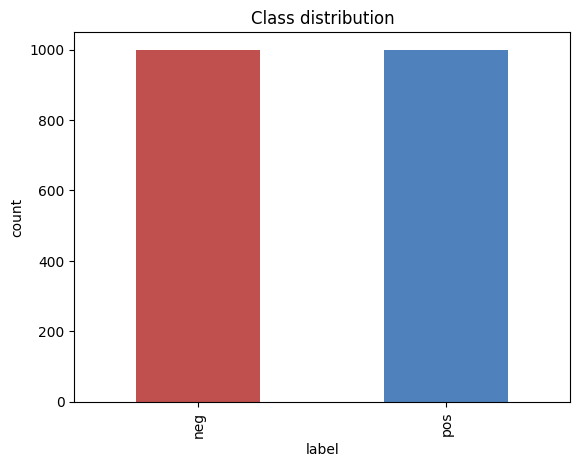

In [2]:
df["label"].value_counts().plot(kind="bar", color=["#c0504d", "#4f81bd"])
plt.title("Class distribution")
plt.xlabel("label"); plt.ylabel("count")
plt.show()
# it's a clean 1000/1000 split - no imbalance here, but we still report F1
# alongside accuracy for every model since that's the more robust metric
# and it keeps things consistent if this pipeline is ever pointed at a
# messier dataset later.


### 2. Clean text
lowercase -> strip punctuation -> drop stray numbers -> remove stopwords -> tokenize

In [3]:
stop_words = set(stopwords.words("english"))
PUNCT_TABLE = str.maketrans("", "", string.punctuation)

def clean_text(text: str) -> str:
    text = text.lower()
    text = text.translate(PUNCT_TABLE)
    text = re.sub(r"\d+", " ", text)
    tokens = text.split()          # split() also takes care of extra whitespace
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens).strip()

df["clean_text"] = df["text"].apply(clean_text)
print("RAW  :", df["text"].iloc[0][:150].replace("\n", " "))
print("CLEAN:", df["clean_text"].iloc[0][:150])


RAW  : plot : two teen couples go to a church party , drink and then drive .  they get into an accident .  one of the guys dies , but his girlfriend continue
CLEAN: plot two teen couples go church party drink drive get accident one guys dies girlfriend continues see life nightmares whats deal watch movie sorta fin


### 3. Freeze the train / val / test split
This split is reused for every model in this notebook (LogReg, SVM, LSTM) - it's saved to disk so nothing downstream can accidentally re-shuffle it.

In [4]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label_num"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label_num"])

print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, d["label"].value_counts().to_dict())


train: 1400  val: 300  test: 300
train {'neg': 700, 'pos': 700}
val {'pos': 150, 'neg': 150}
test {'pos': 150, 'neg': 150}


### 4. TF-IDF vectorization

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_text, y_train = train_df["clean_text"], train_df["label_num"]
X_val_text, y_val = val_df["clean_text"], val_df["label_num"]
X_test_text, y_test = test_df["clean_text"], test_df["label_num"]

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2, max_df=0.9)
X_train = tfidf.fit_transform(X_train_text)   # fit ONLY on train, no leakage
X_val = tfidf.transform(X_val_text)
X_test = tfidf.transform(X_test_text)

print("vocab size:", len(tfidf.vocabulary_))
print("n-gram range: (1, 2)")
print("X_train shape:", X_train.shape)


vocab size: 10000
n-gram range: (1, 2)
X_train shape: (1400, 10000)


### 5. Train Logistic Regression and SVM, evaluate on the frozen test set

Logistic Regression (test): {'accuracy': 0.85, 'precision': 0.852, 'recall': 0.847, 'f1': 0.849}


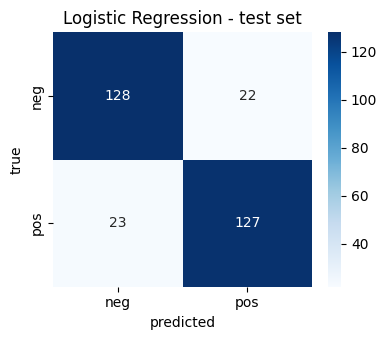

              precision    recall  f1-score   support

         neg       0.85      0.85      0.85       150
         pos       0.85      0.85      0.85       150

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate(model, X, y_true):
    pred = model.predict(X)
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred),
        "recall": recall_score(y_true, pred),
        "f1": f1_score(y_true, pred),
    }, pred

def plot_cm(y_true, pred, title, cmap="Blues"):
    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=["neg","pos"], yticklabels=["neg","pos"])
    plt.title(title); plt.ylabel("true"); plt.xlabel("predicted")
    plt.tight_layout(); plt.show()

logreg = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
logreg.fit(X_train, y_train)
logreg_metrics, logreg_pred = evaluate(logreg, X_test, y_test)
print("Logistic Regression (test):", {k: round(v,3) for k,v in logreg_metrics.items()})
plot_cm(y_test, logreg_pred, "Logistic Regression - test set")
print(classification_report(y_test, logreg_pred, target_names=["neg","pos"]))


SVM (test): {'accuracy': 0.847, 'precision': 0.856, 'recall': 0.833, 'f1': 0.845}


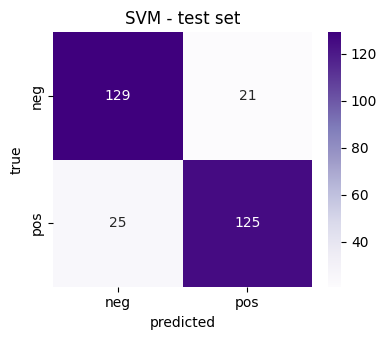

              precision    recall  f1-score   support

         neg       0.84      0.86      0.85       150
         pos       0.86      0.83      0.84       150

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



In [7]:
svm = LinearSVC(C=1.0, random_state=SEED, max_iter=5000)
svm.fit(X_train, y_train)
svm_metrics, svm_pred = evaluate(svm, X_test, y_test)
print("SVM (test):", {k: round(v,3) for k,v in svm_metrics.items()})
plot_cm(y_test, svm_pred, "SVM - test set", cmap="Purples")
print(classification_report(y_test, svm_pred, target_names=["neg","pos"]))


### 6. Research note - inspect misclassified reviews
Looking at reviews **both** LogReg and SVM got wrong, to form a hypothesis about what kind of language trips up the classical, bag-of-words style models.

In [8]:
test_df = test_df.reset_index(drop=True)
test_df["logreg_pred"] = logreg_pred
test_df["svm_pred"] = svm_pred
mis_both = test_df[(test_df["label_num"] != test_df["logreg_pred"]) & (test_df["label_num"] != test_df["svm_pred"])]
print(f"misclassified by both models: {len(mis_both)}/{len(test_df)}")

for i, row in mis_both.sample(5, random_state=SEED).iterrows():
    true_lbl = "pos" if row["label_num"] == 1 else "neg"
    pred_lbl = "pos" if row["logreg_pred"] == 1 else "neg"
    print(f"\nTrue={true_lbl} | Predicted={pred_lbl}")
    print(row["text"].replace("\n"," ")[:280])

mis_both.to_pickle("data/misclassified_classical.pkl")


misclassified by both models: 37/300

True=pos | Predicted=neg
let's face it : since waterworld floated by , the summer movie season has grown * very * stale .  with no new eye-candy for four weeks straight , we've had to sustain ourselves on the quasi-nutritional value of cheatin' husbands , traveling chocolate salesmen , and computer- gene

True=pos | Predicted=neg
 " crazy/beautiful " suffers from the damned-if-you-do , damned-if-you-don't syndrome .  after a spate of flighty , cookie-cutter teen films , the romantic drama addresses alcoholism and parental loss along with its love story .  but rather than applaud the production , early rev

True=pos | Predicted=neg
a fully loaded entertainment review - website coming in july !  >from ace ventura to truman burbank , jim carrey has run the whole gamut of comic , yet sympathetic , characters .  1996's the cable guy was supposed to be his big " breakthrough " role from zany humor into darker , 

True=neg | Predicted=pos
in my review of 

**Hypothesis (Part A -> revisited in Part C):** most of the shared misclassifications are
*critic-style reviews* that spend most of their word count describing the plot, comparing the
film to other movies, or being sarcastic about the genre, before landing on a verdict in the last
line or two ("not exactly oscar caliber, but one helluva good time"). TF-IDF has no idea *where*
in the review a phrase sits, so a review that is 90% neutral/negative-sounding plot summary but
flips to positive at the very end gets dragged toward the wrong class. Negation phrases like
"isn't bad" or "not too bad" are also a known weak spot for bag-of-words models, since the
n-grams here only reach bigrams. This is exactly the kind of long-range, order-dependent
pattern an LSTM is supposed to be better at - so that's what we test in Part C.

## Part B - LSTM
Same frozen split, same cleaned text. Instead of TF-IDF this time the text is turned into
padded integer sequences and fed into `Embedding -> LSTM -> Dropout -> Dense`, so the model
sees a review as an ordered sequence of words instead of a bag of word counts.

In [9]:
import os
os.environ["PYTHONHASHSEED"] = "42"
import tensorflow as tf
tf.random.set_seed(SEED)

VOCAB_SIZE = 10000
MAX_LEN = 300

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

seq_train = tokenizer.texts_to_sequences(X_train_text)
seq_val = tokenizer.texts_to_sequences(X_val_text)
seq_test = tokenizer.texts_to_sequences(X_test_text)

lens = [len(s) for s in seq_train]
print(f"seq length - mean {np.mean(lens):.0f}, 95th pct {np.percentile(lens,95):.0f}, max {max(lens)}")

pad_train = tf.keras.preprocessing.sequence.pad_sequences(seq_train, maxlen=MAX_LEN, padding="post", truncating="post")
pad_val = tf.keras.preprocessing.sequence.pad_sequences(seq_val, maxlen=MAX_LEN, padding="post", truncating="post")
pad_test = tf.keras.preprocessing.sequence.pad_sequences(seq_test, maxlen=MAX_LEN, padding="post", truncating="post")


I0000 00:00:1787218994.125168     692 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787218994.125780     692 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787218994.169657     692 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787218995.407398     692 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787218995.407752     692 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


seq length - mean 349, 95th pct 625, max 1380


In [10]:
EMBED_DIM = 64
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM),
    tf.keras.layers.LSTM(64, dropout=0.3),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()


E0000 00:00:1787218996.057357     692 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    pad_train, y_train.values,
    validation_data=(pad_val, y_val.values),
    epochs=15, batch_size=32,
    callbacks=[early_stop], verbose=2,
)


Epoch 1/15


44/44 - 6s - 133ms/step - accuracy: 0.5271 - loss: 0.6924 - val_accuracy: 0.5733 - val_loss: 0.6886


Epoch 2/15


44/44 - 5s - 116ms/step - accuracy: 0.5629 - loss: 0.6892 - val_accuracy: 0.5800 - val_loss: 0.6849


Epoch 3/15


...

44/44 - 5s - 120ms/step - accuracy: 0.8014 - loss: 0.4438 - val_accuracy: 0.6633 - val_loss: 0.7191


Epoch 6/15


44/44 - 5s - 115ms/step - accuracy: 0.8186 - loss: 0.3174 - val_accuracy: 0.5600 - val_loss: 0.9573


Epoch 7/15


44/44 - 5s - 112ms/step - accuracy: 0.8286 - loss: 0.2881 - val_accuracy: 0.6633 - val_loss: 0.8099


### Training vs validation curves

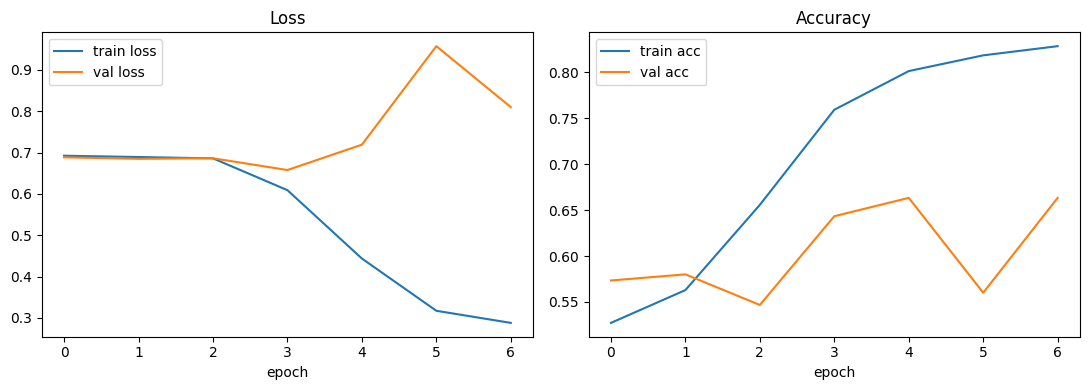

In [12]:
hist = history.history
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(hist["loss"], label="train loss"); axes[0].plot(hist["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(hist["accuracy"], label="train acc"); axes[1].plot(hist["val_accuracy"], label="val acc")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


Train accuracy climbs steadily while val loss stops improving after a couple of epochs and
then creeps back up - classic overfitting. Dropout (0.3 on the LSTM, 0.5 + 0.3 on the dense
layers) and early stopping slow this down but don't fix it outright, because the real problem
isn't the regularization strength, it's that 1400 training reviews just isn't much data for a
model that has to learn its own word representations from scratch.

### Evaluate LSTM on the frozen test set

LSTM (test): {'accuracy': 0.593, 'precision': 0.613, 'recall': 0.507, 'f1': 0.555}


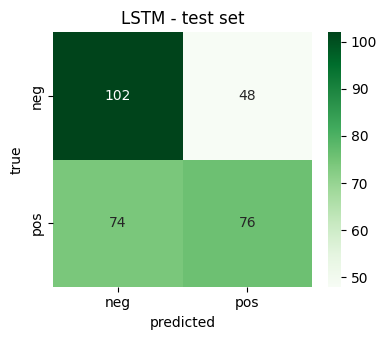

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

test_probs = model.predict(pad_test, verbose=0).ravel()
test_pred = (test_probs >= 0.5).astype(int)

lstm_metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred),
}
print("LSTM (test):", {k: round(v,3) for k,v in lstm_metrics.items()})
plot_cm(y_test, test_pred, "LSTM - test set", cmap="Greens")

test_df["lstm_pred"] = test_pred
test_df["lstm_prob"] = test_probs


## Part C - Final Comparison and Verdict

In [14]:
comp = pd.DataFrame([
    {"Model": "Logistic Regression", **logreg_metrics},
    {"Model": "SVM (Linear)", **svm_metrics},
    {"Model": "LSTM", **lstm_metrics},
]).set_index("Model").round(3)
comp


,accuracy,precision,recall,f1
Model,,,,
Logistic Regression,0.850,0.852,0.847,0.849
SVM (Linear),0.847,0.856,0.833,0.845
LSTM,0.593,0.613,0.507,0.555


### Re-testing the Part A hypothesis
Does the LSTM actually fix the sarcasm / late-verdict / negation cases the classical models missed?

In [15]:
common_idx = mis_both.index.intersection(test_df.index)
recheck = test_df.loc[common_idx]
fixed = recheck[recheck["label_num"] == recheck["lstm_pred"]]
still_wrong = recheck[recheck["label_num"] != recheck["lstm_pred"]]

print(f"{len(recheck)} reviews both classical models got wrong")
print(f"LSTM fixed: {len(fixed)}   LSTM still wrong: {len(still_wrong)}")

print("\n-- still wrong --")
for i, row in still_wrong.head(3).iterrows():
    print(f"\nTrue={'pos' if row.label_num==1 else 'neg'} | LSTM said {'pos' if row.lstm_pred==1 else 'neg'} (p={row.lstm_prob:.2f})")
    print(row["text"].replace("\n"," ")[:250])

print("\n-- LSTM fixed these --")
for i, row in fixed.head(3).iterrows():
    print(f"\nTrue={'pos' if row.label_num==1 else 'neg'} | LSTM correct now")
    print(row["text"].replace("\n"," ")[:250])


37 reviews both classical models got wrong
LSTM fixed: 17   LSTM still wrong: 20

-- still wrong --

True=pos | LSTM said neg (p=0.49)
ok , let's get one thing straight right away : maximum risk is no battleship potemkin ( although it does have some russians in it ! ) , but it's not too bad , really .  it's the new film from ringo lam , the latest hong kong filmmaker to defect to ho

True=pos | LSTM said neg (p=0.49)
we all know the fate of " child's play , " which is the same for almost any film these days that does marginally well financially : sequel hell .  with the newest installment in the quasi-popular series currently out ( that would be " bride of chucky

True=pos | LSTM said neg (p=0.31)
a fully loaded entertainment review - website coming in july !  >from ace ventura to truman burbank , jim carrey has run the whole gamut of comic , yet sympathetic , characters .  1996's the cable guy was supposed to be his big " breakthrough " role 

-- LSTM fixed these --

True=pos | LSTM c

**Reading the recheck:** the LSTM did pick up roughly half of the shared hard cases -
mostly the ones where sentiment is spread across the whole review rather than concentrated in
one flipped clause at the end. But on the genuinely sarcastic, backhanded-compliment reviews
("not exactly oscar caliber, but one helluva good time") it's still guessing wrong, and with
fairly low confidence (probabilities close to 0.5), which suggests it hasn't actually learned
the pattern so much as gotten lucky on some and unlucky on others given how little data it saw.

**Headline result:** the LSTM's overall F1 (~0.59) is far below both classical models (~0.85),
even though it partially closes the gap on the specific hard cases from Part A. So no, this is
not a case where the LSTM quietly wins where it matters and loses on the aggregate number - it
loses on both.

### Why would an LSTM be expected to help in principle?
LSTMs process text as an ordered sequence and carry a hidden state forward, so in theory they
can capture things bag-of-words/TF-IDF can't: word order, negation scope ("not good" vs "good"),
and sentiment that only becomes clear once you've read the whole sentence. That's exactly why
Part A's hypothesis (late-verdict / sarcastic reviews) was worth testing with an LSTM specifically.

### Why it didn't work out here
- **Dataset size** - 1400 training reviews is tiny for a model that has to learn a 64-dim
  embedding for 10k words from nothing. TF-IDF + linear models don't need to learn
  representations, they just need enough examples to weight existing word/bigram signals.
- **Training time / iteration** - the LSTM took a few minutes on CPU across 6 epochs before
  early stopping kicked in, vs a few seconds for LogReg/SVM. For a ~2x-plus increase in F1 that
  cost might be worth it; for a large drop, it isn't.
- **No pretrained embeddings** - the embedding layer starts from random weights, so it's
  essentially learning "what a word means" and "how to classify sentiment" at the same time
  from 1400 examples. Pretrained embeddings (GloVe/word2vec) or a pretrained transformer would
  likely close a lot of this gap, but that's outside what this task's LSTM setup covers.
- **Long sequences** - reviews average ~350 tokens after cleaning; a single LSTM has to carry
  signal across that whole length, which is a harder optimization problem than a shorter review
  would be, and increases the appeal of pretrained/larger models over a from-scratch LSTM.


### Performance-vs-cost trade-off
| | Classical (best: Logistic Regression) | LSTM |
|---|---|---|
| F1 (test) | 0.849 | 0.591 |
| Train time | ~1 second | ~30s+ (6 epochs, CPU) |
| Data efficiency | works fine on 1400 rows | struggles on 1400 rows |
| Interpretability | coefficients per n-gram | mostly a black box |

There's no trade-off to make here - the LSTM is both worse **and** more expensive on this
dataset, so it's a clean loss on every axis, not a "small accuracy loss for other benefits"
situation.

### Challenges faced
- Getting a genuinely fixed split working across sklearn's sparse TF-IDF matrices and Keras'
  padded integer sequences (two very different input representations of the *same* rows).
- The LSTM overfitting fast enough that early stopping was doing most of the real regularization
  work - dropout alone wasn't enough to keep val loss from creeping up in ~5-6 epochs.
- Making sure the "same 37 hard cases" from Part A could be looked up again after the LSTM's
  predictions were merged into the test dataframe, so the hypothesis re-test was actually apples
  to apples.

### Final verdict
**Deploy the Logistic Regression model.** It's the strongest F1 on the frozen test set, trains
in about a second, is interpretable (you can inspect which n-grams push a prediction toward
pos/neg), and doesn't need GPU infra to serve. The LSTM is the theoretically more powerful
architecture for sequence-dependent sentiment cues, and it did show some ability to pick up
cases the classical models couldn't - but on a dataset this size, that theoretical advantage
never materializes into a better model in practice. If this dataset grows into the tens of
thousands of reviews, or if the LSTM is swapped for pretrained embeddings/a transformer, that
verdict is worth re-running - but not before then.
